<a href="https://colab.research.google.com/github/minjxxyu0/ESAA/blob/main/YB_0522_%E1%84%8B%E1%85%A7%E1%86%AB%E1%84%89%E1%85%B3%E1%86%B8%E1%84%86%E1%85%AE%E1%86%AB%E1%84%8C%E1%85%A6_%E1%84%8E%E1%85%A1%E1%84%8B%E1%85%AF%E1%86%AB%E1%84%8E%E1%85%AE%E1%86%A8%E1%84%89%E1%85%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 데이터 로드
from sklearn.datasets import fetch_openml
mnist=fetch_openml('mnist_784', version=1)

In [ ]:
# train, test split
X_train = mnist['data'][:60000]
y_train = mnist['target'][:60000]
X_test = mnist['data'][60000:]
y_test = mnist['target'][60000:]

* 랜덤포레스트에 적용

In [ ]:
# 랜덤포레스트에 적용 (n_estimators=10, random_state=42)
from sklearn.ensemble import RandomForestClassifier
rnd_clf = RandomForestClassifier(n_estimators=10, random_state=42)
rnd_clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [ ]:
# 정확도 결과
a = rnd_clf.score(X_test, y_test)
print(a)

0.9492


# 1. PCA

* PCA로 변환한 데이터 세트에 랜덤 포레스트 적용

In [ ]:
# PCA 라이브러리 불러오기
from sklearn.decomposition import PCA

In [ ]:
# PCA 적용 95% : n_components=0.95
pca = PCA(n_components=0.95)
X_train_reduced = pca.fit_transform(X_train, y_train)

In [ ]:
# PCA 이후 랜덤포레스트 훈련
rnd_clf2 = RandomForestClassifier(n_estimators=10, random_state=42)
rnd_clf2.fit(X_train_reduced, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [ ]:
# 정확도 결과 (X_test도 PCA 적용해야합니다.)
X_test_reduced = pca.transform(X_test)

acc_test = rnd_clf2.score(X_test_reduced, y_test)
print(acc_test)

0.8925


**관련 문제**

* PCA모델을 와인 데이터셋에 적용하여 차원을 축소하고 그 결과를 그래프로 나타내보세요.

(1) 필요한 모듈 불러오기

In [ ]:
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

(2)  load_wine을 사용해 데이터셋을 생성한다.

In [ ]:
train = load_wine()
X = train.data
y = train.target

(3) X에 표준 스케일링(Standard scaling)을 적용하여 X_scaled을 생성한다.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

(4) PCA 모델을 X에 적용하여 2개의 차원으로 추출한다. 단, random_state=1234로 설정한다.

In [ ]:
#PCA 모델을 X_scaled에 적용하여 2개의 차원으로 추출한다.
pca = PCA(n_components=2, random_state=1234)
X_pca = pca.fit_transform(X_scaled)

(5) 추출한 피처를 그래프로 나타내라.

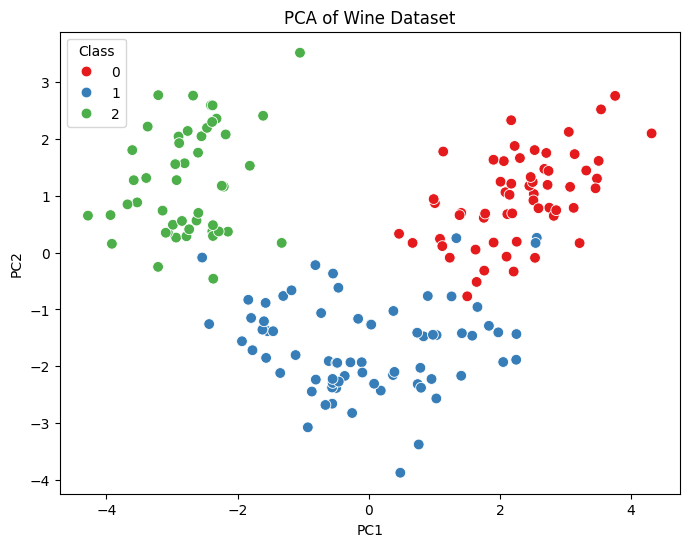

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set1', s=60)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Wine Dataset')
plt.legend(title='Class')
plt.show()

# 2. LDA

- LDA로 변환한 데이터 세트에 랜덤 포레스트 적용

In [ ]:
# LDA 라이브러리 불러오기
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [ ]:
# LDA 적용 : n_components=5
lda = LinearDiscriminantAnalysis(n_components=5)
X_train_lda = lda.fit_transform(X_train, y_train)

In [ ]:
# LDA 이후 랜덤포레스트 훈련
rnd_clf_lda = RandomForestClassifier(n_estimators=10, random_state=42)
rnd_clf_lda.fit(X_train_lda, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [ ]:
# 정확도 결과 (X_test도 LDA 적용해야합니다.
X_test_lda = lda.transform(X_test)

acc_test_lda = rnd_clf_lda.score(X_test_lda, y_test)
print(acc_test_lda)

0.8301
